In [1]:
# cil imports
from cil.framework import ImageData, ImageGeometry
from cil.framework import AcquisitionGeometry, AcquisitionData

from cil.plugins.astra.operators import ProjectionOperator

from cil.utilities.display import show2D

# External imports
from phantominator import shepp_logan
import numpy as np
from scipy.linalg import svd
import matplotlib.pyplot as plt


## Setting defaults and finding A from phantom data

In [ ]:
# number of pixels and angles
n_pixels = 50
n_angles = 50

# other input
cmap = 'rainbow'
device = 'cpu'

In [3]:
# Angles
angles = np.linspace(0, 180, n_angles, endpoint=False, dtype=np.float32)


# Setup acquisition geometry
# with sufficient number of projections
ag = AcquisitionGeometry.create_Parallel2D()\
                            .set_angles(angles)\
                            .set_panel(n_pixels, pixel_size=1/n_pixels)

# Setup image geometry
ig = ImageGeometry(voxel_num_x=n_pixels, 
                   voxel_num_y=n_pixels, 
                   voxel_size_x=1/n_pixels, 
                   voxel_size_y=1/n_pixels)

# Get phantom
phantom = ImageData(np.flip(shepp_logan(n_pixels)), geometry = ig)
size_phantom = phantom.shape

c:\Users\femke\anaconda3\envs\cil_demos_cpu\Lib\site-packages\cil\framework\data_container.py:112: UserWarning: Over-riding geometry.dtype with data.dtype
  warnings.warn("Over-riding geometry.dtype with data.dtype", UserWarning)


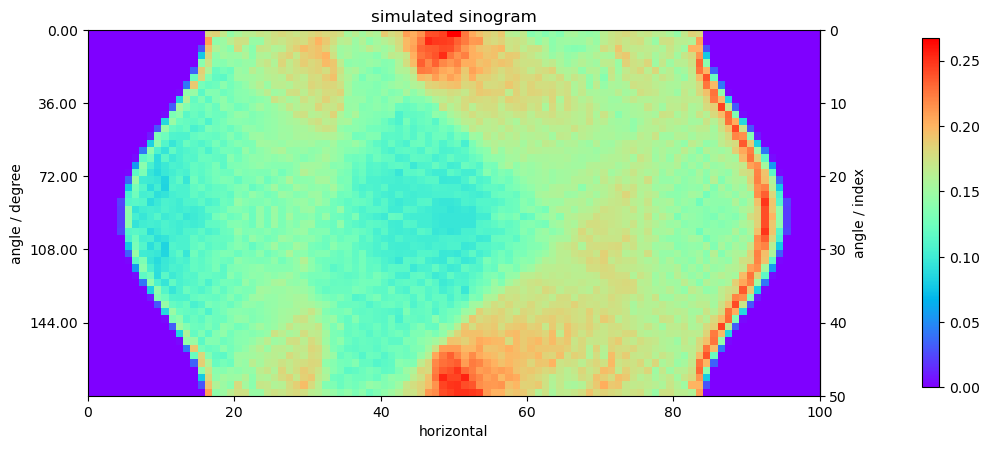

In [4]:
# Create projection operator using Astra-Toolbox.
A = ProjectionOperator(ig, ag, device)

# Create an acquisition data (numerically)
sino = A.direct(phantom)

# Visualise data
show2D(sino, 'simulated sinogram', cmap=cmap, size=(10,10), origin='upper-left')

# Create A and find singular values

In [5]:
zero_image = ig.allocate(0.0)
size_sino = sino.size # size sino = n_angles * n_pixels
total_pixels = n_pixels ** 2

# Columns of A represent the pixels, rows of A the detected data (number of angles=size sino)
A_radon = np.zeros((size_sino, total_pixels))

pixel_index = 0

# Run over all pixels, make them equal 1, one by
for pixel_number_y in range(n_pixels):
    for pixel_number_x in range(n_pixels):
        zero_image.as_array()[pixel_number_y, pixel_number_x] = 1.0

        # We compute A by considering AI
        sinogram_basis = A.direct(zero_image).as_array()

        A_radon[:, pixel_index] = sinogram_basis.reshape(size_sino,)

        zero_image.as_array()[pixel_number_y, pixel_number_x] = 0.0
        pixel_index = pixel_index + 1

print('The size of A_radon is', A_radon.shape)

The size of A_radon is (5000, 10000)


c:\Users\femke\anaconda3\envs\cil_demos_cpu\Lib\site-packages\cil\framework\data_container.py:112: UserWarning: Over-riding geometry.dtype with data.dtype
  warnings.warn("Over-riding geometry.dtype with data.dtype", UserWarning)


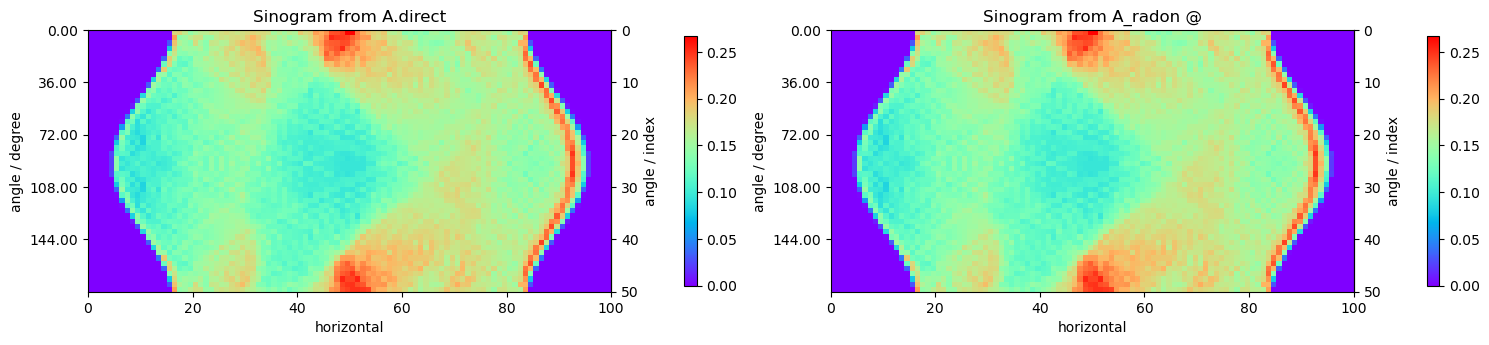

c:\Users\femke\anaconda3\envs\cil_demos_cpu\Lib\site-packages\cil\framework\data_container.py:112: UserWarning: Over-riding geometry.dtype with data.dtype
  warnings.warn("Over-riding geometry.dtype with data.dtype", UserWarning)


2.711058413938429e-06

In [6]:
# Au = b, with b the sinogram, A the computed radonmatrix and u the phantom
sino_new = A_radon @ phantom.as_array().reshape(total_pixels,)
sino_new = AcquisitionData(sino_new.reshape(sino.shape), geometry=ag) # not sure what this does


# Visualise data
show2D([sino, sino_new], ['Sinogram from A.direct', 'Sinogram from A_radon @'], \
       cmap=cmap, num_cols=3, size=(15,10), origin='upper-left')

# error computation
diff = sino-sino_new
diff.norm()

Computing singular values of the A radon matrix

In [7]:
sing_values = svd(A_radon, compute_uv=False)

<class 'numpy.ndarray'>
[1.000e+00 2.000e+00 3.000e+00 ... 4.998e+03 4.999e+03 5.000e+03]
5000


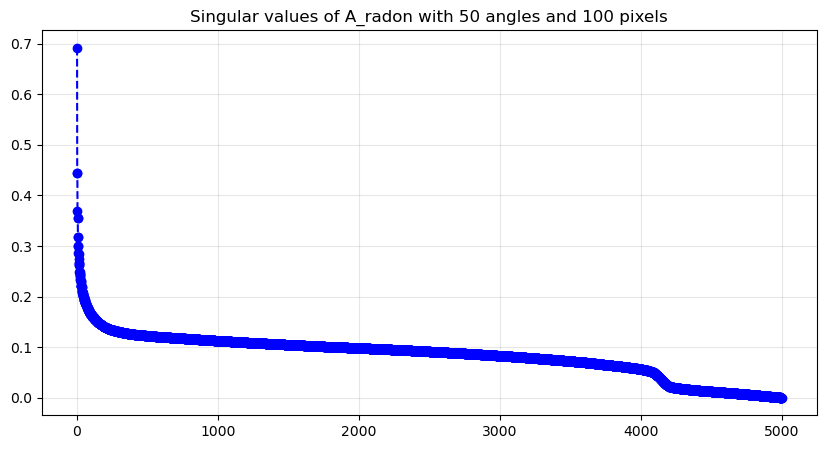

In [ ]:
print(type(sing_values))
length = sing_values.size
x = np.linspace(1, length, length)
print(x)
print(length)

plt.figure(figsize=(10,5))
plt.title(f'Singular values of A_radon with {n_angles} angles and {n_pixels} pixels')
plt.grid(alpha =0.3)
plt.semilogy(x, sing_values, '--bo')

## Doing it for more cases

In [9]:
def radon_A(n_angles, n_pixels):

    # Setup acquisition geometry
    # Angles
    angles = np.linspace(0, 180, n_angles, endpoint=False, dtype=np.float32)

    # with sufficient number of projections
    ag = AcquisitionGeometry.create_Parallel2D()\
                                .set_angles(angles)\
                                .set_panel(n_pixels, pixel_size=1/n_pixels)

    # Setup image geometry
    ig = ImageGeometry(voxel_num_x=n_pixels, 
                    voxel_num_y=n_pixels, 
                    voxel_size_x=1/n_pixels, 
                    voxel_size_y=1/n_pixels)
    
    # Creating pojection operator
    proj_operator = ProjectionOperator(ig, ag, device)

    zero_image = ig.allocate(0.0)
    size_sino = n_angles*n_pixels 
    total_pixels = n_pixels ** 2

    # Columns of A represent the pixels, rows of A the detected data (number of angles=size sino)
    A_radon = np.zeros((size_sino, total_pixels))

    pixel_index = 0

    # Run over all pixels, make them equal 1, one by
    for pixel_number_y in range(n_pixels):
        for pixel_number_x in range(n_pixels):
            zero_image.as_array()[pixel_number_y, pixel_number_x] = 1.0

            # We compute A by considering AI
            sinogram_basis = proj_operator.direct(zero_image).as_array()

            A_radon[:, pixel_index] = sinogram_basis.reshape(size_sino,)

            zero_image.as_array()[pixel_number_y, pixel_number_x] = 0.0
            pixel_index = pixel_index + 1

    return A_radon

def compute_cond(n_angles, n_pixels):
    A_radon = radon_A(n_angles, n_pixels)
    sing_vals = svd(A_radon, compute_uv=False)

    cond_number = sing_vals[0]/sing_vals[-1]

    return cond_number, sing_vals

0.8750170352833512 1.921416677847966e-16


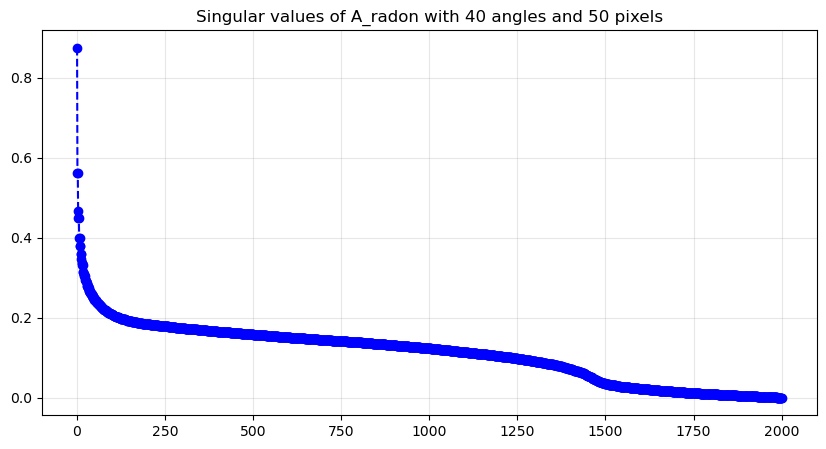

In [ ]:
n_angles = 40
n_pixels = 50

sing_vals = compute_cond(n_angles, n_pixels)[1]
length = sing_vals.size
x = np.linspace(1, length, length)
print(sing_vals[0], sing_vals[-1])

plt.figure(figsize=(10,5))
plt.title(f'Singular values of A_radon with {n_angles} angles and {n_pixels} pixels')
plt.grid(alpha =0.3)
plt.semilogy(x, sing_vals, '--bo')

iteration 0
iteration 1
iteration 2
iteration 3
iteration 4
iteration 5
iteration 6
iteration 7
iteration 8
iteration 9


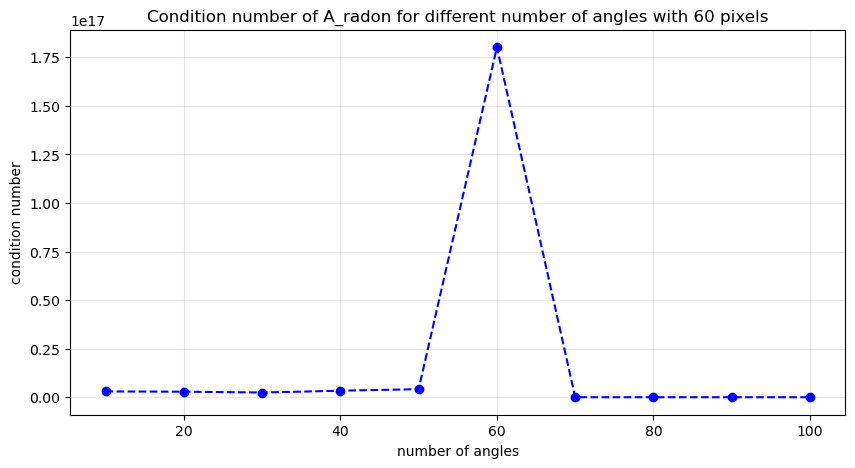

In [ ]:
n_angles = np.array([10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
pixels = 60
cond_number = []
i = 0
for theta in n_angles: 
    cond_number.append(compute_cond(theta, pixels)[0])
    print(f'iteration {i}')
    i += 1

plt.figure(figsize=(10,5))
plt.semilogy(n_angles, cond_number, '--bo')
plt.xlabel('number of angles')
plt.ylabel('condition number')
plt.title(f'Condition number of A_radon for different number of angles with {pixels} pixels')
plt.grid(alpha=0.3)
